In [38]:
import sys
import torch
import math
from xray_gaussian_rasterization_voxelization import (
    GaussianRasterizationSettings,
    GaussianRasterizer,
    GaussianVoxelizationSettings,
    GaussianVoxelizer,
)

sys.path.append("./")
from r2_gaussian.gaussian.gaussian_model import GaussianModel
from r2_gaussian.dataset.cameras import Camera
from r2_gaussian.arguments import PipelineParams

In [39]:
from r2_gaussian.dataset import Scene
from r2_gaussian.gaussian import GaussianModel, render, query, initialize_gaussian

In [40]:
from argparse import ArgumentParser
from r2_gaussian.arguments import (
    ModelParams,
    PipelineParams,
    get_combined_args,
)

In [41]:
from argparse import Namespace

In [42]:
parser = ArgumentParser(description="Testing script parameters")
model = ModelParams(parser, sentinel=True)

pipeline = PipelineParams(parser)


# Namespace で引数を手動指定
args = Namespace(
    source_path="data/synthetic_dataset/cone_ntrain_75_angle_360/0_chest_cone",
    model_path="output/95e359ad-b",
    data_device="cuda",
    scale_min=0.0005,
    scale_max=0.5,
    eval=True
)

dataset = model.extract(args)
scene = Scene(
    dataset
)

Reading camera 75/75 for train
Reading camera 100/100 for test
Loading Training Cameras
Loading Test Cameras


In [43]:
# Set up Gaussians
gaussians = GaussianModel(None)  # scale_bound will be loaded later
loaded_iter = initialize_gaussian(gaussians, dataset, -1)
scene.gaussians = gaussians

Loading trained model at iteration 30000


In [44]:
import cv2
from cv2 import aruco
from pathlib import Path

print(cv2.__version__)

squareLength = 0.04 # @param {type:"number"}
markerLength = 0.03 # @param {type:"number"}
path = "." # @param {type:"string"}
path = Path(path)
dictionary = aruco.getPredefinedDictionary(aruco.DICT_4X4_50)
board = aruco.CharucoBoard((7, 5), squareLength, markerLength, dictionary)
imboard = board.generateImage((3500, 2500))

4.11.0


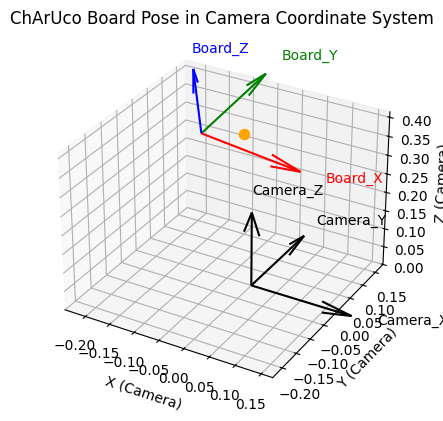

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

# ChArUco ボードの同次変換行列（カメラ座標系→ボード座標系）
charuco_path =  "volunme_slicing_display/charuco_camera_transformation.npz"
charuco_tf = np.load(charuco_path)["charuco_tf"]
# カメラ座標系は原点・単位行列
camera_tf = np.eye(4)
charuco_center = np.array([-0.00781352, -0.01640093, 0.4141831])

def plot_frame(ax, tf, charuco_center, label, colors=('r','g','b')):
    """4x4 同次変換行列 tf をもとに座標軸を描画する関数"""
    origin = tf[:3, 3] 
    x_axis = tf[:3, 0]
    y_axis = tf[:3, 1]
    z_axis = tf[:3, 2]
    
    # charuco_centerを表示
    ax.scatter(*charuco_center, color='orange', s=50, label='ChArUco Center')


    ax.quiver(*origin, *x_axis, length=0.2, normalize=True, color=colors[0])
    ax.quiver(*origin, *y_axis, length=0.2, normalize=True, color=colors[1])
    ax.quiver(*origin, *z_axis, length=0.2, normalize=True, color=colors[2])
    ax.text(*(origin + x_axis * 0.25), f'{label}_X', color=colors[0])
    ax.text(*(origin + y_axis * 0.25), f'{label}_Y', color=colors[1])
    ax.text(*(origin + z_axis * 0.25), f'{label}_Z', color=colors[2])

# 3D プロットの準備
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# カメラ座標系を黒で描画
plot_frame(ax, camera_tf, charuco_center, 'Camera', colors=('k','k','k'))
# ボード座標系を色付きで描画
plot_frame(ax, charuco_tf, charuco_center, 'Board', colors=('r','g','b'))

# 軸ラベルとタイトル
ax.set_xlabel('X (Camera)')
ax.set_ylabel('Y (Camera)')
ax.set_zlabel('Z (Camera)')
ax.set_title('ChArUco Board Pose in Camera Coordinate System')

# アスペクト比を揃える
points = np.vstack((camera_tf[:3,3], charuco_tf[:3,3]))
max_range = points.ptp(axis=0).max() / 2.0
mid = points.mean(axis=0)
ax.set_xlim(mid[0] - max_range, mid[0] + max_range)
ax.set_ylim(mid[1] - max_range, mid[1] + max_range)
ax.set_zlim(mid[2] - max_range, mid[2] + max_range)

# 表示
plt.show()

In [67]:
# カメラを取得する
# 1. カメラ位置を上からに固定する場合 
# 2. ChArUcoボードの中心位置(not Pose)を元にカメラ位置を決定する場合
# 3. ChArUcoボードの中心位置と向きを元にカメラ位置を決定する場合

# 1. カメラ位置を上からに固定する場合
def get_camera_from_top():
    # カメラの位置を上からに固定
    _r = np.array([[0, 1, 0], [1, 0, 0], [0, 0, -1]])  # 上からの視点
    _t = np.array([0, 0, 3])  # Z軸方向に+3.0の位置にカメラを配置
    
    return Camera(
            colmap_id=65,
            scanner_cfg=None,
            R = _r,
            T = _t, 
            angle=0.8366643629487514,
            mode=1,
            FoVx=0.5565993180102227,
            FoVy=0.5565993180102227,
            image=torch.zeros((1, 512, 512)),
            image_name="none",
            uid=15,
        )

# 2. ChArUcoボードの中心位置を元にカメラ位置を決定する場合
def get_camera_from_center(charuco_center):
    tf = np.load(charuco_path)["charuco_tf"]
    origin = tf[:3, 3]  # ボードの中心位置
    print("Origin:", origin)

    normal_vector = charuco_center
    def project_onto_plane(vec, normal):
        """ベクトル vec を法線 normal を持つ平面に射影する関数"""
        normal = normal / np.linalg.norm(normal)
        return vec - np.dot(vec, normal) * normal

    x_axis = project_onto_plane(tf[:3, 0], normal_vector)
    print("X Axis:", x_axis)
    y_axis = project_onto_plane(tf[:3, 1], normal_vector)
    print("Y Axis:", y_axis)
    z_axis = normal_vector  # Z軸は法線ベクトルとする

    # shapeを(3, 4)に変更
    new_tf = np.array([x_axis, y_axis, z_axis, origin]).T
    print("New Transformation Matrix:\n", new_tf)
    
    _r = np.array([y_axis, x_axis, -z_axis]).T  # 回転行列を作成

    print("Rotation Matrix:\n", _r)
    _t = origin + z_axis * 4  # Z軸方向に+3.0の位置にカメラを配置
    
    
    return Camera(
            colmap_id=65,
            scanner_cfg=None,
            R = _r,
            T = _t, 
            angle=0.8366643629487514,
            mode=1,
            FoVx=0.5565993180102227,
            FoVy=0.5565993180102227,
            image=torch.zeros((1, 512, 512)),
            image_name="none",
            uid=15,
        )

# # 2. ChArUcoボードの位置
# def get_camera_from_tf():
#     tf = np.load(charuco_path)["charuco_tf"]
#     origin = tf[:3, 3] 
#     print("Origin:", origin)
#     x_axis = tf[:3, 0]
#     print("X Axis:", x_axis)
#     y_axis = tf[:3, 1]
#     print("Y Axis:", y_axis)
#     z_axis = tf[:3, 2]
#     print("Z Axis:", z_axis)

#     _r = tf[:3, :3]
#     print("Rotation Matrix:\n", _r)
#     _r = np.array([[0, 1.2, 0], [1, 0, 0], [0, 0, -1]])
#     print("Modified Rotation Matrix:\n", _r)
#     _t = tf[:3, 3] + np.array([0, 0, 3])   # Z軸方向に+2.0の位置にカメラを配置
    
    
#     return Camera(
#             colmap_id=65,
#             scanner_cfg=None,
#             R = _r,
#             T = _t, 
#             angle=0.8366643629487514,
#             mode=1,
#             FoVx=0.5565993180102227,
#             FoVy=0.5565993180102227,
#             image=torch.zeros((1, 512, 512)),
#             image_name="none",
#             uid=15,
#         )
get_camera_from_center(charuco_center)

Origin: [-0.07095734 -0.0509944   0.41439975]
X Axis: [ 0.99166197 -0.07307883  0.0158138 ]
Y Axis: [0.09178877 0.9758952  0.04037534]
New Transformation Matrix:
 [[ 0.99166197  0.09178877 -0.00781352 -0.07095734]
 [-0.07307883  0.9758952  -0.01640093 -0.0509944 ]
 [ 0.0158138   0.04037534  0.4141831   0.41439975]]
Rotation Matrix:
 [[ 0.09178877  0.99166197  0.00781352]
 [ 0.9758952  -0.07307883  0.01640093]
 [ 0.04037534  0.0158138  -0.4141831 ]]


Camera()

(0.0, 0.4143997522137419)

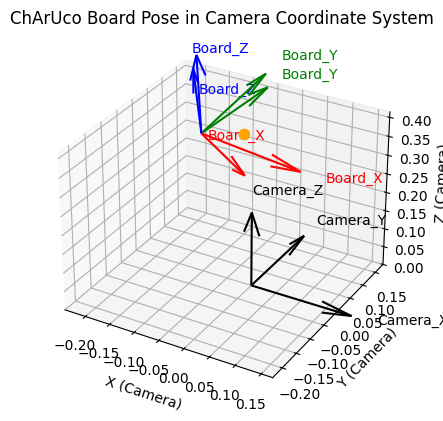

In [68]:
# 3D プロットの準備
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# カメラ座標系を黒で描画
plot_frame(ax, camera_tf, charuco_center, 'Camera', colors=('k','k','k'))
# ボード座標系を色付きで描画
plot_frame(ax, charuco_tf, charuco_center, 'Board', colors=('r','g','b'))


new_tf = np.array([
	[0.09166197,  0.09178877, -0.00781352, -0.07095734],
	[-0.07307883,  0.9758952,  -0.01640093, -0.0509944 ],
	[0.0158138,   0.04037534,  0.4141831,   0.41439975]
])
plot_frame(ax, new_tf, charuco_center, 'Board', colors=('r','g','b'))

# 軸ラベルとタイトル
ax.set_xlabel('X (Camera)')
ax.set_ylabel('Y (Camera)')
ax.set_zlabel('Z (Camera)')
ax.set_title('ChArUco Board Pose in Camera Coordinate System')

# アスペクト比を揃える
points = np.vstack((camera_tf[:3,3], charuco_tf[:3,3]))
max_range = points.ptp(axis=0).max() / 2.0
mid = points.mean(axis=0)
ax.set_xlim(mid[0] - max_range, mid[0] + max_range)
ax.set_ylim(mid[1] - max_range, mid[1] + max_range)
ax.set_zlim(mid[2] - max_range, mid[2] + max_range)

In [69]:
# gaussiansをカットする
def cut_gaussians_by_plane(gaussians, tf, d=0.1):
    with torch.no_grad():
        origin = tf[:3, 3] 
        normal = tf[:3, 2]
        # 正規化された法線ベクトル
        normal = normal / np.linalg.norm(normal)
        normal = torch.from_numpy(normal).to(gaussians._xyz.device, dtype=gaussians._xyz.dtype)

        # originもtensorに変換
        origin = torch.from_numpy(origin).to(gaussians._xyz.device, dtype=gaussians._xyz.dtype)

        # 各centerから平面までの符号付き距離を計算
        distance = torch.abs(torch.matmul(gaussians._xyz - origin, normal))

        mask  = distance > d
        gaussians._density[mask] = -100


def cut_gaussians_beyond_plane(gaussians, tf, d=1e-1):
    with torch.no_grad():
        origin = tf[:3, 3]
        normal = tf[:3, 2]
        # 正規化された法線ベクトル
        normal = normal / np.linalg.norm(normal)
        normal = torch.from_numpy(normal).to(gaussians._xyz.device, dtype=gaussians._xyz.dtype)

        # originもtensorに変換
        origin = torch.from_numpy(origin).to(gaussians._xyz.device, dtype=gaussians._xyz.dtype)

        # 各centerから平面までの符号付き距離を計算
        distance = torch.matmul(gaussians._xyz - origin, normal)

        mask  = distance < 0
        gaussians._density[mask] = -100

Origin: [-0.07095734 -0.0509944   0.41439975]
X Axis: [ 0.99166197 -0.07307883  0.0158138 ]
Y Axis: [0.09178877 0.9758952  0.04037534]
New Transformation Matrix:
 [[ 0.99166197  0.09178877 -0.00781352 -0.07095734]
 [-0.07307883  0.9758952  -0.01640093 -0.0509944 ]
 [ 0.0158138   0.04037534  0.4141831   0.41439975]]
Rotation Matrix:
 [[ 0.09178877  0.99166197  0.00781352]
 [ 0.9758952  -0.07307883  0.01640093]
 [ 0.04037534  0.0158138  -0.4141831 ]]


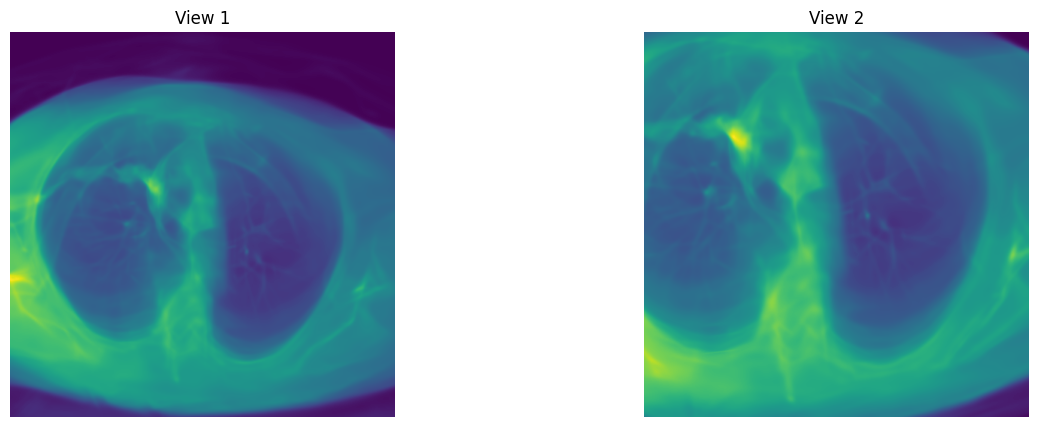

In [70]:
import copy

views = [get_camera_from_top(), get_camera_from_center(charuco_center)]
renderings = []
copy_gaussians = copy.deepcopy(gaussians)
#cut_gaussians_by_plane(copy_gaussians, charuco_tf, d=0.01)
cut_gaussians_beyond_plane(copy_gaussians, charuco_tf, d=0.01)
for i, view in enumerate(views):
    rendering = render(view, copy_gaussians, pipeline)["render"][0].detach().cpu().numpy()
    renderings.append(rendering)
    
plt.figure(figsize=(15, 5))
for i, r in enumerate(renderings):
    plt.subplot(1, len(renderings), i + 1)
    plt.imshow(r)
    plt.axis('off')
    plt.title(f"View {i + 1}")

In [15]:
import numpy as np

def spherical_to_cartesian(theta, phi, radius):
    x  = radius * np.sin(theta) * np.cos(phi)
    y = radius * np.sin(theta) * np.sin(phi)
    z = radius * np.cos(theta)
    return np.array([x, y, z])

def look_at_transform(
        center,
        lookat,
        up,
    ):
    z = lookat - center

    z = z / np.linalg.norm(z)

    x = np.cross(up, z)
    if np.all(x == 0):
        x = np.cross(up, z + np.array([1e-6, 1e-6, 1e-6]))  # Avoid zero vector
    x = x / np.linalg.norm(x)

    y = np.cross(z, x)
    R = np.stack([x, y, z], axis=1)
    t = -R.T @ center
    view_matrix = np.eye(4)
    view_matrix[:3, :3] = R
    view_matrix[:3, 3] = t
    return view_matrix

def view_matrix_from_spherical(
        theta,
        phi,
        radius,
        lookat = np.array([0, 0, 0]),
        up = np.array([0, 0, 1])
    ):
    center = spherical_to_cartesian(theta, phi, radius)
    return look_at_transform(center, lookat, up)

def get_camera(theta, phi, radius, up=np.array([0, 0, 1])):
    theta = np.array(theta)
    phi = np.array(phi)
    w2c = view_matrix_from_spherical(theta, phi, radius, up=up)
    _r = w2c[:3, :3]
    print("Rotation Matrix:", _r)
    _t = w2c[:3, 3]

    return Camera(
        colmap_id=65,
        scanner_cfg=None,
        R = _r,
        T = _t, 
        angle=0.8366643629487514,
        mode=1,
        FoVx=0.5565993180102227,
        FoVy=0.5565993180102227,
        image=torch.zeros((1, 512, 512)),
        image_name="none",
        uid=15,
    )

Rotation Matrix: [[-0.  1.  0.]
 [ 1.  0.  0.]
 [ 0.  0. -1.]]
Rotation Matrix: [[-0.000000e+00  6.123234e-17 -1.000000e+00]
 [ 1.000000e+00  0.000000e+00  0.000000e+00]
 [ 0.000000e+00 -1.000000e+00 -6.123234e-17]]
Rotation Matrix: [[ 0.00000000e+00  1.00000000e+00 -6.12323400e-17]
 [ 6.12323400e-17 -6.12323400e-17 -1.00000000e+00]
 [-1.00000000e+00 -3.74939946e-33 -6.12323400e-17]]


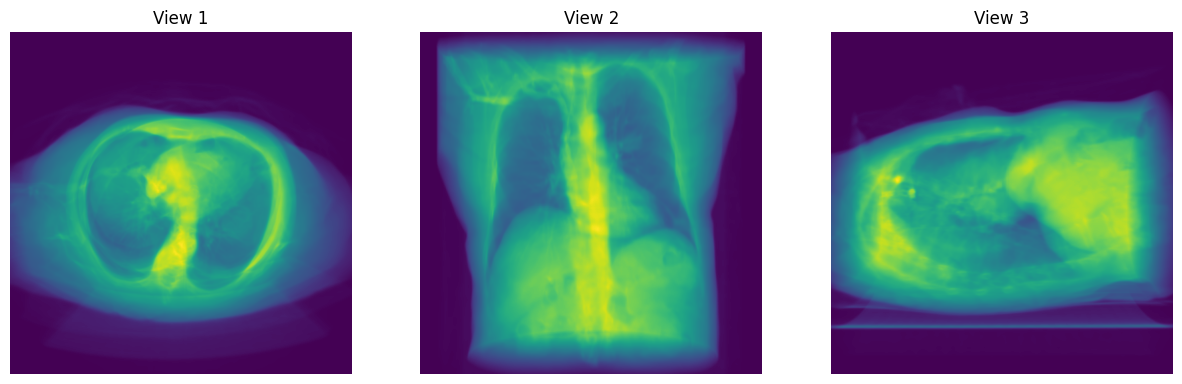

In [16]:
views = [get_camera(0, 0, 4, up=np.array([1, 0, 0])), get_camera(np.pi/2, 0, 4, up=np.array([1, 0, 0])), get_camera(np.pi/2, np.pi/2, 4, up=np.array([1, 0, 0]))]

renderings = []
for i, view in enumerate(views):
    rendering = render(view, gaussians, pipeline)["render"][0].detach().cpu().numpy()
    renderings.append(rendering)
    
plt.figure(figsize=(15, 5))
for i, r in enumerate(renderings):
    plt.subplot(1, len(renderings), i + 1)
    plt.imshow(r)
    plt.axis('off')
    plt.title(f"View {i + 1}")

In [19]:
import copy

Rotation Matrix: [[-0.  1.  0.]
 [ 1.  0.  0.]
 [ 0.  0. -1.]]


Text(0.5, 1.0, 'Image at z=0.01')

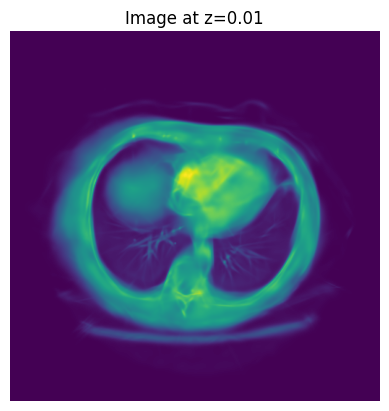

In [24]:
def get_image(theta, phi, radius, z, slice=True, up=np.array([1, 0, 0])):
    copy_gaussians = copy.deepcopy(gaussians)

    camera_center = spherical_to_cartesian(theta, phi, radius + z)
    normal_vector = camera_center / np.linalg.norm(camera_center)

    origin = np.array([0, 0, 0]) - normal_vector * z
    if slice:
        cut_gaussians_by_plane(copy_gaussians, origin, normal=normal_vector)
    else:
        cut_gaussians_beyond_plane(copy_gaussians, origin, normal=normal_vector)

    view = get_camera(theta, phi, radius, up=up)

    rendering = render(view, copy_gaussians, pipeline)["render"][0].detach().cpu().numpy()
    return rendering

rendering = get_image(0, 0, 4, 0.1)
plt.imshow(rendering)
plt.axis('off')
plt.title("Image at z=0.01")


In [17]:
import tqdm

In [18]:
# アニメーションを作成(gifファイルとして出力)
import imageio
import matplotlib.cm as cm

def create_gif(renderings, filename="output.gif", duration=0.1, colormap='jet'):
    """
    レンダリング結果からGIFアニメーションを作成
    
    Parameters:
    -----------
    renderings : list
        レンダリング結果の配列
    filename : str
        保存するファイル名
    duration : float
        フレーム間の時間（秒）
    colormap : str
        使用するカラーマップ名 ('jet', 'viridis', 'plasma'等)
    """
    # カラーマップを取得
    cmap = cm.get_cmap(colormap)
    
    # 画像配列を作成
    images = []
    for rendering in renderings:
        # 画像を0-1の範囲に正規化
        if rendering.min() != rendering.max():  # 分母が0にならないように確認
            normalized = (rendering - rendering.min()) / (rendering.max() - rendering.min())
        else:
            normalized = rendering
            
        # カラーマップを適用
        colored = cmap(normalized)
        
        # RGBA画像をRGB uint8に変換
        rgb_uint8 = (colored[:, :, :3] * 255).astype(np.uint8)
        images.append(rgb_uint8)
    
    # GIFとして保存
    imageio.mimsave(filename, images, duration=duration)
    print(f"GIFをファイル '{filename}' に保存しました")

# 使用例 - zを変化させたレンダリング結果からGIF作成
z_values = np.linspace(-1, 1, 50)  # フレーム数を50に減らして処理速度向上
renderings_slice = []
renderings = []

for z in tqdm.tqdm(z_values, desc="Z平面でのレンダリング"):
    rendering = get_image(0, 0, 4, z, slice=False)
    renderings.append(rendering)

    rendering = get_image(0, 0, 4, z, slice=True)
    renderings_slice.append(rendering)

# GIF作成（複数のカラーマップでテスト）
create_gif(renderings_slice, filename="slices_jet.gif", duration=0.1, colormap='jet')
create_gif(renderings_slice, filename="slices_viridis.gif", duration=0.1, colormap='viridis')

create_gif(renderings, filename="beyond_jet.gif", duration=0.1, colormap='jet')
create_gif(renderings, filename="beyond_viridis.gif", duration=0.1, colormap='viridis')



Z平面でのレンダリング: 100%|██████████| 50/50 [00:00<00:00, 72.33it/s]
C:\Users\Maemaeko\AppData\Local\Temp\ipykernel_21348\2858116868.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap)


GIFをファイル 'slices_jet.gif' に保存しました
GIFをファイル 'slices_viridis.gif' に保存しました
GIFをファイル 'beyond_jet.gif' に保存しました
GIFをファイル 'beyond_viridis.gif' に保存しました


In [19]:
# 使用例 - thetaを変化させたレンダリング結果からGIF作成
theta_values = np.linspace(0, np.pi/2, 50)  # フレーム数を50に減らして処理速度向上

#phi_values = np.linspace(0, 2 * np.pi, 50)
renderings_theta_phi = []
renderings_theta_phi_slice = []
for theta in tqdm.tqdm(theta_values, desc="ThetaとPhiでのレンダリング"):
    #for phi in phi_values:
    rendering = get_image(theta, 0, 4, 0.01)
    renderings_theta_phi_slice.append(rendering)

    rendering = get_image(theta, 0, 4, 0.01, slice=False)
    renderings_theta_phi.append(rendering)

# GIF作成（複数のカラーマップでテスト）
create_gif(renderings_theta_phi_slice, filename="theta_slice_jet.gif", duration=0.1, colormap='jet')
create_gif(renderings_theta_phi_slice, filename="theta_slice_viridis.gif", duration=0.1, colormap='viridis')
create_gif(renderings_theta_phi, filename="theta_beyond_jet.gif", duration=0.1, colormap='jet')
create_gif(renderings_theta_phi, filename="theta_beyond_viridis.gif", duration=0.1, colormap='viridis')

ThetaとPhiでのレンダリング: 100%|██████████| 50/50 [00:00<00:00, 86.35it/s]
C:\Users\Maemaeko\AppData\Local\Temp\ipykernel_21348\2858116868.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap)


GIFをファイル 'theta_slice_jet.gif' に保存しました
GIFをファイル 'theta_slice_viridis.gif' に保存しました
GIFをファイル 'theta_beyond_jet.gif' に保存しました
GIFをファイル 'theta_beyond_viridis.gif' に保存しました


In [31]:
# 使用例 - phiを変化させたレンダリング結果からGIF作成
phi_values = np.linspace(0.01, np.pi, 50)  # フレーム数を50に減らして処理速度向上
renderings_phi = []
renderings_phi_slice = []
for phi in tqdm.tqdm(phi_values, desc="Phiでのレンダリング"):
    rendering = get_image(np.pi/2, phi, 4, 0.01, up=np.array([0, 0, -1]))
    renderings_phi_slice.append(rendering)
    rendering = get_image(np.pi/2, phi, 4, 0.01, slice=False, up=np.array([0, 0, -1]))
    renderings_phi.append(rendering)
# GIF作成（複数のカラーマップでテスト）
create_gif(renderings_phi_slice, filename="phi_slice_jet.gif", duration=0.1, colormap='jet')
create_gif(renderings_phi_slice, filename="phi_slice_viridis.gif", duration=0.1, colormap='viridis')
create_gif(renderings_phi, filename="phi_beyond_jet.gif", duration=0.1, colormap='jet')
create_gif(renderings_phi, filename="phi_beyond_viridis.gif", duration=0.1, colormap='viridis')

Phiでのレンダリング: 100%|██████████| 50/50 [00:00<00:00, 83.48it/s]
/tmp/ipykernel_1044/2858116868.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap)


GIFをファイル 'phi_slice_jet.gif' に保存しました
GIFをファイル 'phi_slice_viridis.gif' に保存しました
GIFをファイル 'phi_beyond_jet.gif' に保存しました
GIFをファイル 'phi_beyond_viridis.gif' に保存しました


/tmp/ipykernel_1044/3739943846.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left')


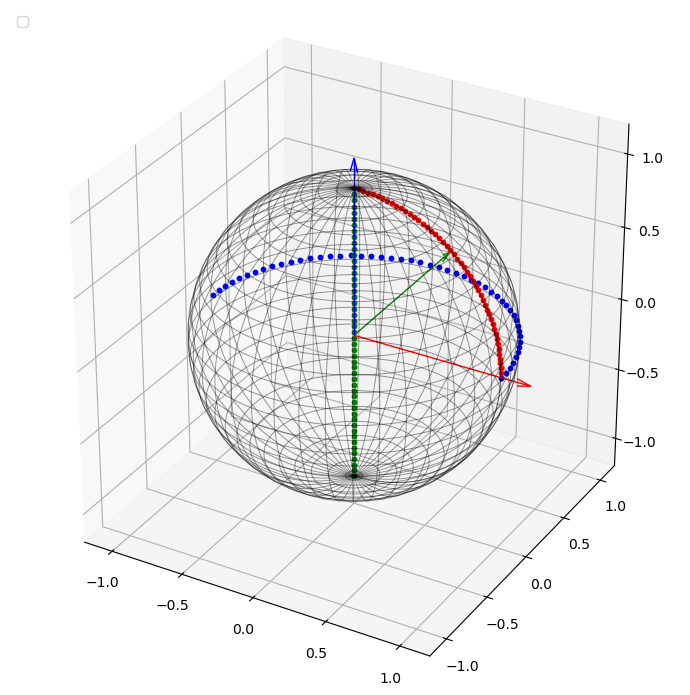

In [33]:
# 球面座標系の可視化（ブラッシュアップ版）

import numpy as np
import matplotlib.pyplot as plt

# 球面座標系 (r, theta, phi) からデカルト座標 (x, y, z) への変換
def spherical_to_cartesian(r, theta, phi):
    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    z = r * np.cos(theta)
    return x, y, z

# パラメータ範囲
r = 1
theta = np.linspace(0, np.pi, 60)      # 分解能を上げる
phi = np.linspace(0, 2 * np.pi, 120)

# メッシュグリッド作成
theta_grid, phi_grid = np.meshgrid(theta, phi)

# デカルト座標に変換
x, y, z = spherical_to_cartesian(r, theta_grid, phi_grid)

# 3Dプロット
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_wireframe(x, y, z, color='k', linewidth=0.7, alpha=0.4)

# 球面座標の軸を描画
ax.quiver(0, 0, 0, 1.2, 0, 0, color='r', arrow_length_ratio=0.08, linewidth=1)
ax.quiver(0, 0, 0, 0, 1.2, 0, color='g', arrow_length_ratio=0.08, linewidth=1)
ax.quiver(0, 0, 0, 0, 0, 1.2, color='b', arrow_length_ratio=0.08, linewidth=1)

# theta, phi の例点をプロット
# sample_theta = np.pi / 4
# sample_phi = np.pi / 3
# sample_x, sample_y, sample_z = spherical_to_cartesian(r, sample_theta, sample_phi)
# ax.scatter(sample_x, sample_y, sample_z, color='magenta', s=80, label='(θ, φ) example')

z_values = np.linspace(-1, 1, 50)  # フレーム数を50に減らして処理速度向上
for z in z_values:
    sample_x, sample_y, sample_z = spherical_to_cartesian(r, 0, 0)
    look_at_transform
    ax.scatter(sample_x, sample_y, z, color='green', s=10)


theta_values = np.linspace(np.pi / 2, 0, 50) 
phi_values = np.zeros_like(theta_values)
for theta, phi in zip(theta_values, phi_values):
    sample_x, sample_y, sample_z = spherical_to_cartesian(r, theta, phi)
    ax.scatter(sample_x, sample_y, sample_z, color='red', s=10)


phi_values = np.linspace(0, np.pi, 50)
theta_values = np.ones_like(phi_values) * np.pi / 2 
for theta, phi in zip(theta_values, phi_values):
    sample_x, sample_y, sample_z = spherical_to_cartesian(r, theta, phi)
    ax.scatter(sample_x, sample_y, sample_z, color='blue', s=10)



# ラベル・タイトル
# ax.set_xlabel('X', fontsize=12)
# ax.set_ylabel('Y', fontsize=12)
# ax.set_zlabel('Z', fontsize=12)
# ax.set_title('球面座標系の可視化', fontsize=15)
ax.set_box_aspect([1,1,1])

# 凡例
ax.legend(loc='upper left')

# スケール調整
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])

plt.tight_layout()
plt.show()